<a href="https://colab.research.google.com/github/PMSense/AI-Security-/blob/main/Slam_Laqtib_project3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Topic Classification using Naive Bayes

**Solution**

# Intro
---
In this project, you'll work with text data from newsgroup posts on a variety of topics. You'll train classifiers to distinguish posts by topics inferred from the text. Whereas with digit classification, where each input is relatively **dense** (represented as a 28x28 matrix of pixels, many of which are non-zero), here each document is relatively **sparse** (represented as a **bag-of-words**). Only a few words of the total vocabulary are active in any given document. The assumption is that a label depends only on the count of words, not their order.

The `sklearn` documentation on feature extraction may be useful:
http://scikit-learn.org/stable/modules/feature_extraction.html

Each problem can be addressed succinctly with the included packages -- please don't add any more. Grading will be based on writing clean, commented code, along with a few short answers.

As always, you're welcome to work on the project in groups and discuss ideas on Slack, but <b> please prepare your own write-up with your own code. </b>

## Grading
---
- Make sure to answer every part in every question.
 - There are 7 questions and one extra credit question.
 - Read carefully what is asked including the notes.
 - Additional points may be deducted if:
   - the code is not clean and well commented,
   - and if the functions or answers are too long.

 ## Requirements:
---
1. Comment your code.
1. All graphs should have titles, label for each axis, and if needed a legend. It should be understandable on its own.
1. All code must run on colab.research.google.com
1. You should not import any additional libraries.
1. Try and minimize the use of the global namespace (meaning keep things in functions).



In [ ]:
# This tells matplotlib not to try opening a new window for each plot.
%matplotlib inline

# General libraries.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SK-learn libraries for learning.
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB

# SK-learn libraries for evaluation.
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report

# SK-learn library for importing the newsgroup data.
from sklearn.datasets import fetch_20newsgroups

# SK-learn libraries for feature extraction from text.
from sklearn.feature_extraction.text import *

import nltk

Load the data, stripping out metadata so that only textual features will be used, and restricting documents to 4 specific topics. By default, newsgroups data is split into training and test sets, but here the test set gets further split into development and test sets.  (If you remove the categories argument from the fetch function calls, you'd get documents from all 20 topics.)

In [ ]:
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']
newsgroups_train = fetch_20newsgroups(subset='train',
                                      remove=('headers', 'footers', 'quotes'),
                                      categories=categories)
newsgroups_test  = fetch_20newsgroups(subset='test',
                                      remove=('headers', 'footers', 'quotes'),
                                      categories=categories)

num_test = int(len(newsgroups_test.target) / 2)
test_data, test_labels   = newsgroups_test.data[num_test:], newsgroups_test.target[num_test:]
dev_data, dev_labels     = newsgroups_test.data[:num_test], newsgroups_test.target[:num_test]
train_data, train_labels = newsgroups_train.data, newsgroups_train.target

print('training label shape:', train_labels.shape)
print('dev label shape:',      dev_labels.shape)
print('test label shape:',     test_labels.shape)
print('labels names:',         newsgroups_train.target_names)

training label shape: (2034,)
dev label shape: (676,)
test label shape: (677,)
labels names: ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.religion.misc']


### Question 1: Examining your data
---

 1. For each of the first 5 training examples, print the text of the message along with the label (checkout newsgroups_train.target_names).

In [ ]:
def Q1(num_examples=5):
    ### STUDENT START ###
    # Iterate through the first 'num_examples' of the training data.
    for i in range(num_examples):
        # Get the integer target label for the current document.
        label_index = train_labels[i]
        # Use the label_index to look up the human-readable category name.
        label_name = newsgroups_train.target_names[label_index]

        # Get the text content of the document.
        document_text = train_data[i]

        # Print the information in a readable format.
        print(f"Example {i+1}:")
        print(f"Label indexed {label_index}: {label_name}\n")
        print(document_text)
        print("\n" + "="*80 + "\n")
    ### STUDENT END ###

Q1(5)

Example 1:
Label indexed 1: comp.graphics

Hi,

I've noticed that if you only save a model (with all your mapping planes
positioned carefully) to a .3DS file that when you reload it after restarting
3DS, they are given a default position and orientation.  But if you save
to a .PRJ file their positions/orientation are preserved.  Does anyone
know why this information is not stored in the .3DS file?  Nothing is
explicitly said in the manual about saving texture rules in the .PRJ file. 
I'd like to be able to read the texture rule information, does anyone have 
the format for the .PRJ file?

Is the .CEL file format available from somewhere?

Rych


Example 2:
Label indexed 3: talk.religion.misc



Seems to be, barring evidence to the contrary, that Koresh was simply
another deranged fanatic who thought it neccessary to take a whole bunch of
folks with him, children and all, to satisfy his delusional mania. Jim
Jones, circa 1993.


Nope - fruitcakes like Koresh have been demonstrating such

In [ ]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(train_data)
print(X.shape)
vectorizer.get_feature_names_out()

(2034, 26879)


array(['00', '000', '0000', ..., 'zware', 'zwarte', 'zyxel'], dtype=object)

### Question 2: Text representation
---

1. Transform the training data into a matrix of **word** unigram feature vectors.
  1. What is the size of the vocabulary?
  1. What is the average number of non-zero features per example?  
  1. What is the fraction of the non-zero entries in the matrix?  
  1. What are the 0th and last feature strings (in alphabetical order)?
  - _Use `CountVectorization` and its `.fit_transform` method.  Use `.nnz` and `.shape` attributes, and `.get_feature_names` method._
1. Now transform the training data into a matrix of **word** unigram feature vectors restricting to the vocabulary with these 4 words: ["atheism", "graphics", "space", "religion"].  Confirm the size of the vocabulary.
  1. What is the average number of non-zero features per example?
  - _Use `CountVectorization(vocabulary=...)` and its `.transform` method._
1. Now transform the training data into a matrix of **character** bigram and trigram feature vectors.  
  1. What is the size of the vocabulary?
  - _Use `CountVectorization(analyzer=..., ngram_range=...)` and its `.fit_transform` method._
1. Now transform the training data into a matrix of **word** unigram feature vectors and prune words that appear in fewer than 10 documents.  
  1. What is the size of the vocabulary?<br/>
  - _Use `CountVectorization(min_df=...)` and its `.fit_transform` method._
1. Now again transform the training data into a matrix of **word** unigram feature vectors.
 1. What is the fraction of words in the development vocabulary that is missing from the training vocabulary?
 - _Hint: Build vocabularies for both train and dev and look at the size of the difference._

Notes:
* `.fit_transform` makes 2 passes through the data: first it computes the vocabulary ("fit"), second it converts the raw text into feature vectors using the vocabulary ("transform").
* `.fit_transform` and `.transform` return sparse matrix objects.  See about them at http://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.sparse.csr_matrix.html.

In [ ]:
def Q2():
    ### STUDENT START ###

    print("Part 1 - Word Unigram Features:")
    # We create a standard CountVectorizer to convert the training text into a
    # matrix of word counts (unigrams).
    vectorizer1 = CountVectorizer()
    X1 = vectorizer1.fit_transform(train_data)

    # The size of the vocabulary is the number of unique words found, which
    # corresponds to the number of columns in the resulting matrix.
    vocab_size = X1.shape[1]
    print(f"\t. Size of vocabulary (words or columns): {vocab_size}")

    # The average number of non-zero features is the total count of non-zero
    # elements (.nnz) divided by the number of documents (rows).
    avg_nonzero = X1.nnz / X1.shape[0]
    print(f"\t. Average non-zero features per example: {avg_nonzero:.4f}")

    # The fraction of non-zero entries is the total count of non-zero elements
    # divided by the total number of cells in the matrix (rows * columns).
    total_entries = X1.shape[0] * X1.shape[1]
    fraction_nonzero = X1.nnz / total_entries
    print(f"\t. Fraction of non-zero entries (sparsity): {fraction_nonzero:.6f}")

    # get_feature_names_out() returns a sorted list of the vocabulary.
    features = vectorizer1.get_feature_names_out()
    print(f"\t. 0th feature string (alphabetical): '{features[0]}'")
    print(f"\t. Last feature string (alphabetical): '{features[-1]}'")

    print("-" * 50)

    print("Part 2 - Restricted Vocabulary:")
    # Here, we force the vectorizer to only count a predefined list of words.
    restricted_vocab = ["atheism", "graphics", "space", "religion"]

    # When a vocabulary is provided, we don't need to 'fit' the data.
    # The vectorizer already knows what features to look for.
    vectorizer2 = CountVectorizer(vocabulary=restricted_vocab)
    X2 = vectorizer2.transform(train_data)

    print(f"\t. Confirmed vocabulary size: {X2.shape[1]}")

    avg_nonzero2 = X2.nnz / X2.shape[0]
    print(f"\t. Average non-zero features per example: {avg_nonzero2:.4f}")

    print("-" * 50)

    print("Part 3 - Character Bi-grams and Tri-grams:")
    # Instead of words, we analyze sequences of characters.
    # analyzer='char' tells it to look at characters, not words.
    # ngram_range=(2, 3) tells it to create features for 2-char and 3-char sequences.
    vectorizer3 = CountVectorizer(analyzer='char', ngram_range=(2, 3))
    X3 = vectorizer3.fit_transform(train_data)

    print(f"\t. Size of vocabulary: {X3.shape[1]}")

    print("-" * 50)

    print("Part 4 - Pruning with min_df")
    # We create word unigrams but ignore words that are too rare.
    # min_df=10 means a word must appear in at least 10 documents to be included.
    # This is a common technique to remove noise and reduce vocabulary size.
    vectorizer4 = CountVectorizer(min_df=10)
    X4 = vectorizer4.fit_transform(train_data)

    print(f"\t. Size of vocabulary after pruning: {X4.shape[1]}")

    print("-" * 50)

    print("Part 5 - Vocabulary Mismatch (Train vs. Dev):")
    # We check how many words from the development set are new (out-of-vocabulary)
    # compared to the words seen during training.

    # Build vocabulary from the training data
    train_vectorizer = CountVectorizer()
    train_vectorizer.fit(train_data)
    train_vocab = set(train_vectorizer.get_feature_names_out())

    # Build vocabulary from the development data
    dev_vectorizer = CountVectorizer()
    dev_vectorizer.fit(dev_data)
    dev_vocab = set(dev_vectorizer.get_feature_names_out())

    # Find words in the dev vocab that are not in the train vocab
    missing_words = dev_vocab - train_vocab

    # Calculate the fraction of the dev vocabulary that is missing
    fraction_missing = len(missing_words) / len(dev_vocab)

    print(f"\t. Fraction of dev vocabulary missing from train vocabulary: {fraction_missing:.4f}")

    ### STUDENT END ###

Q2()

Part 1 - Word Unigram Features:
	. Size of vocabulary (words or columns): 26879
	. Average non-zero features per example: 96.7060
	. Fraction of non-zero entries (sparsity): 0.003598
	. 0th feature string (alphabetical): '00'
	. Last feature string (alphabetical): 'zyxel'
--------------------------------------------------
Part 2 - Restricted Vocabulary:
	. Confirmed vocabulary size: 4
	. Average non-zero features per example: 0.2684
--------------------------------------------------
Part 3 - Character Bi-grams and Tri-grams:
	. Size of vocabulary: 35478
--------------------------------------------------
Part 4 - Pruning with min_df
	. Size of vocabulary after pruning: 3064
--------------------------------------------------
Part 5 - Vocabulary Mismatch (Train vs. Dev):
	. Fraction of dev vocabulary missing from train vocabulary: 0.2479


### Question 3: Initial model evaluation
---

1. Transform the training and development data to matrices of word unigram feature vectors.
1. Produce several k-Nearest Neigbors models by varying k, including one with k set to optimize f1 score.  For each model, show the k value and f1 score.
1. Produce several Naive Bayes models by varying smoothing (alpha), including one with alpha set approximately to optimize f1 score.  For each model, show the alpha value and f1 score.
1. Produce several Logistic Regression models by varying L2 regularization strength (C), including one with C set approximately to optimize f1 score.  For each model, show the C value, f1 score, and sum of squared weights for each topic.
1. Why doesn't k-Nearest Neighbors work well for this problem?
1. Why doesn't Logistic Regression work as well as Naive Bayes does?
1. What is the relationship between logistic regression's sum of squared weights vs. C value?

Notes:
* Train on the transformed training data.
* Evaluate on the transformed development data.
* You can use `CountVectorizer` and its `.fit_transform` and `.transform` methods to transform data.
* You can use `KNeighborsClassifier(...)` to produce a k-Nearest Neighbors model.
* You can use `MultinomialNB(...)` to produce a Naive Bayes model.
* You can use `LogisticRegression(C=..., solver="liblinear", multi_class="auto")` to produce a Logistic Regression model.
* You can use `LogisticRegression`'s `.coef_` method to get weights for each topic.
* You can use `metrics.f1_score(..., average="weighted")` to compute f1 score.

In [ ]:
def Q3():
    ### STUDENT START ###

    print("Step 1 - \n\tVectorizing data...")
    # Convert the raw text into numerical vectors using CountVectorizer.
    # The vocabulary is learned from the training data, and then that same
    # vocabulary is used to transform the development data.
    vectorizer = CountVectorizer()
    X_train = vectorizer.fit_transform(train_data)
    X_dev = vectorizer.transform(dev_data)
    print("\tVectorization complete.\n")

    print("Step 2 - K-Nearest Neighbors Evaluation")
    k_values = [1, 3, 5, 7, 9, 11, 13]
    # Store f1 scores to find the best k
    knn_f1_scores = []

    for k in k_values:
        # Create and train the KNN model
        knn_model = KNeighborsClassifier(n_neighbors=k)
        knn_model.fit(X_train, train_labels)

        # Predict on the development set
        knn_predictions = knn_model.predict(X_dev)

        # Calculate and store the F1 score
        f1 = metrics.f1_score(dev_labels, knn_predictions, average='weighted')
        knn_f1_scores.append(f1)
        print(f"\tk = {k:2d}, F1 Score = {f1:.4f}")

    # Find the best k value based on the F1 score
    best_k_index = np.argmax(knn_f1_scores)
    print(f"\n\tOptimal k is approximately {k_values[best_k_index]} with an F1 score of {knn_f1_scores[best_k_index]:.4f}.\n")

    print("Step 3 - Multinomial Naive Bayes Evaluation")
    alpha_values = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
    nb_f1_scores = []

    for alpha in alpha_values:
        # Create and train the Naive Bayes model
        nb_model = MultinomialNB(alpha=alpha)
        nb_model.fit(X_train, train_labels)

        # Predict on the development set
        nb_predictions = nb_model.predict(X_dev)

        # Calculate and store the F1 score
        f1 = metrics.f1_score(dev_labels, nb_predictions, average='weighted')
        nb_f1_scores.append(f1)
        print(f"\talpha = {alpha:6.4f}, F1 Score = {f1:.4f}")

    # Find the best alpha value based on the F1 score
    best_alpha_index = np.argmax(nb_f1_scores)
    print(f"\n\tOptimal alpha is approximately {alpha_values[best_alpha_index]} with an F1 score of {nb_f1_scores[best_alpha_index]:.4f}.\n")

    # --- Step 4: Logistic Regression Evaluation ---
    print("Step 4 - Logistic Regression Evaluation")
    c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    lr_f1_scores = []

    for C in c_values:
        # Create and train the Logistic Regression model
        lr_model = LogisticRegression(C=C, solver="liblinear", random_state=42)
        lr_model.fit(X_train, train_labels)

        # Predict on the development set
        lr_predictions = lr_model.predict(X_dev)

        # Calculate the F1 score
        f1 = metrics.f1_score(dev_labels, lr_predictions, average='weighted')
        lr_f1_scores.append(f1)

        # Calculate the sum of squared weights for each topic (class)
        # model.coef_ has shape (n_classes, n_features)
        sum_sq_weights = (lr_model.coef_ ** 2).sum(axis=1)

        print(f"\tC = {C:7.3f}, F1 Score = {f1:.4f}, Sum of Squared Weights = {sum_sq_weights}")

    # Find the best C value based on the F1 score
    best_c_index = np.argmax(lr_f1_scores)
    print(f"\n\tOptimal C is approximately {c_values[best_c_index]} with an F1 score of {lr_f1_scores[best_c_index]:.4f}.\n")

    ### STUDENT END ###

Q3()

Step 1 - 
	Vectorizing data...
	Vectorization complete.

Step 2 - K-Nearest Neighbors Evaluation
	k =  1, F1 Score = 0.4018
	k =  3, F1 Score = 0.4042
	k =  5, F1 Score = 0.4370
	k =  7, F1 Score = 0.4415
	k =  9, F1 Score = 0.4354
	k = 11, F1 Score = 0.4086
	k = 13, F1 Score = 0.4224

	Optimal k is approximately 7 with an F1 score of 0.4415.

Step 3 - Multinomial Naive Bayes Evaluation
	alpha = 0.0001, F1 Score = 0.7628
	alpha = 0.0010, F1 Score = 0.7703
	alpha = 0.0100, F1 Score = 0.7752
	alpha = 0.1000, F1 Score = 0.7903
	alpha = 0.5000, F1 Score = 0.7863
	alpha = 1.0000, F1 Score = 0.7777

	Optimal alpha is approximately 0.1 with an F1 score of 0.7903.

Step 4 - Logistic Regression Evaluation
	C =   0.001, F1 Score = 0.6193, Sum of Squared Weights = [0.16509345 0.20095275 0.18067094 0.18724278]
	C =   0.010, F1 Score = 0.6647, Sum of Squared Weights = [2.54153099 2.93970937 2.86246912 2.25002927]
	C =   0.100, F1 Score = 0.6966, Sum of Squared Weights = [27.12953099 24.66144866 27.

ANSWER:

**Why doesn't k-Nearest Neighbors work well for this problem?**

This why k-Nearest Neighbors (KNN) struggles with this text classification problem:

- High Dimensionality: With thousands of words as features, all data points become far apart from each other, making the concept of "distance" between documents become meaningless.
- Data Sparsity: Document vectors are mostly zeros, making it hard to find true similarities.
- Slow Predictions: It's too slow because it must compare every new document to all training documents. With thousands of documents and features, this becomes very inefficient


**Why doesn't Logistic Regression work as well as Naive Bayes does?**

Here is why Logistic Regression can be outperformed by Naive Bayes for problem:

In short, the "naive" assumption of Naive Bayes makes it a robust and effective model for this task, while the complexity of Logistic Regression can be its downfall without very careful tuning.

- Naive Bayes' Simplicity is a Strength: Naive Bayes makes a strong (and technically wrong) assumption that all words are independent. This acts as a powerful form of regularization, preventing the model from overfitting on high dimensional, sparse text data. It learns general trends rather than complex word interactions.

- Logistic Regression is Prone to Overfitting: Logistic Regression tries to learn a specific weight for every single word. With tens of thousands of words (aka features), it can easily overfit by giving too much importance to words that are just noise in the training data, failing to generalize well to new documents.


**What is the relationship between logistic regression's sum of squared weights vs. C value?**

There is a direct relationship: as the C value increases, the sum of squared weights also increases. C is the inverse of regularization strength. It controls the penalty for model complexity.

- Small C: Means strong regularization. The model is heavily penalized for having large weights, forcing them to be small. This results in a low sum of squared weights.

- Large C: Means weak regularization. The penalty is minimal, allowing the model to learn larger weights to better fit the training data. This results in a high sum of squared weights.


### Question 4: Feature exploration
---

1. Transform the data to a matrix of word **bigram** feature vectors.  Produce a Logistic Regression model.
1. For each topic, find the 5 features with the largest weights (not absolute value). If there are no overlaps, you can expect 20 features in total.
1. Show a 20 row (features) x 4 column (topics) table of the weights. So, for each of the features (words) found, we show their weight for all topics.
1. Do you see any surprising features in this table?

Notes:
* Train on the transformed training data.
* You can use `CountVectorizer` and its `.fit_transform` method to transform data.
* You can use `LogisticRegression(C=0.5, solver="liblinear", multi_class="auto")` to produce a Logistic Regression model.
* You can use `LogisticRegression`'s `.coef_` method to get weights for each topic.
* You can use `np.argsort` to get indices sorted by element value.


In [ ]:
def Q4():
    ### STUDENT START ###

    print("Step 1 - \n\tVectorizing data with word bigrams...")
    # We use CountVectorizer with ngram_range=(2, 2) to create features
    # that are sequences of two adjacent words (bigrams).
    vectorizer = CountVectorizer(ngram_range=(2, 2))
    X_train_bigram = vectorizer.fit_transform(train_data)
    print("\tVectorization complete.\n")

    print("Step 2 - \n\tTraining Logistic Regression model...")
    # We train the model on the bigram feature matrix. C=0.5 is chosen
    # to provide moderate regularization.
    lr_model = LogisticRegression(C=0.5, solver="liblinear", random_state=42)
    lr_model.fit(X_train_bigram, train_labels)
    print("\tTraining complete.\n")

    print("Step 3 - Finding top 5 features for each topic...")
    # We'll find the 5 bigrams with the largest positive weights for each class.

    # Get the learned feature names (bigrams) and the model's weights
    feature_names = np.array(vectorizer.get_feature_names_out())
    weights = lr_model.coef_

    # Use a set to store the unique top features across all topics
    top_features_set = set()
    num_top_features = 5

    for i, topic_name in enumerate(newsgroups_train.target_names):
        # np.argsort returns indices that would sort the array.
        # The last 5 indices correspond to the 5 largest weights.
        top_indices = np.argsort(weights[i])[-num_top_features:]

        # Add the corresponding feature names to our set
        top_features_set.update(feature_names[top_indices])

    print("Step 4 - Create a table of the weights")
    # Convert the set to a sorted list for consistent table ordering.
    sorted_top_features = sorted(list(top_features_set))

    # Create a mapping from feature name to its original index for quick lookup.
    vocab_map = {name: idx for idx, name in enumerate(feature_names)}

    # Prepare data for the pandas DataFrame
    table_data = {}
    for i, topic_name in enumerate(newsgroups_train.target_names):
        # For each topic, get the weight for every feature in our top features list
        topic_weights = [weights[i][vocab_map[feature]] for feature in sorted_top_features]
        table_data[topic_name] = topic_weights

    # Create and display the DataFrame
    weights_df = pd.DataFrame(table_data, index=sorted_top_features)

    # Display the full table
    pd.set_option('display.max_rows', len(weights_df))
    print("\n\tTop 20 Bigram Feature Weights Across All Topics\n")
    print(weights_df)
    pd.reset_option('display.max_rows')

    ### STUDENT END ###

Q4()

Step 1 - 
	Vectorizing data with word bigrams...
	Vectorization complete.

Step 2 - 
	Training Logistic Regression model...
	Training complete.

Step 3 - Finding top 5 features for each topic...
Step 4 - Create a table of the weights

	Top 20 Bigram Feature Weights Across All Topics

               alt.atheism  comp.graphics  sci.space  talk.religion.misc
and such         -0.204269      -0.337509   0.590524           -0.218202
are you           0.446953      -0.248257  -0.097135           -0.305625
but he           -0.190019      -0.216871  -0.137402            0.491875
cheers kent       0.555720      -0.697918  -0.663766            0.534808
claim that        0.605549      -0.199067  -0.274345           -0.140364
comp graphics    -0.292166       0.801208  -0.370885           -0.285186
ignorance is     -0.158011      -0.171075  -0.139580            0.504305
in advance       -0.459351       0.832567  -0.438501           -0.418453
is there         -0.340882       0.754998  -0.468249      

ANSWER:

what's highly surprising is:
- 'cheers kent' has strong porisitive weights for both groups alt.atheism and talk.religion.misc.  Kent was active in both debates

- 'looking for' and 'in advance'have massive positive weights for comp.graphics, while they have nothing to do with graphics (fascinating)

- 'claim that', 'are you' and 'was just' all have strong positive weights for alt.atheism. Debates about atheism often involve "are you claiming that..." or "I was just reading..."  

### Question 5: Pre-processing for text
---

To improve generalization, it is common to try preprocessing text in various ways before splitting into words. For example, you could try transforming strings to lower case, replacing sequences of numbers with single tokens, removing various non-letter characters, and shortening long words.

1. Produce a Logistic Regression model (with no preprocessing of text). **Note that you may need to override the "default" preprocessing with an identity function**. Evaluate and show its f1 score and size of the dictionary.
1. Produce an improved Logistic Regression model by preprocessing the text. Evaluate and show its f1 score and size of the vocabulary.  Aim for an improvement in f1 score of 0.02. **Note: this is actually very hard**.
1. How much did the improved model reduce the vocabulary size?

Notes:
* Things you can try: ** ???: Anything else we can suggest**
 - Look at default pre-processing done.
 - Removing stop words.
 - Experiment with different ways of getting rid of apostrophe's such as replacing them with spaces or with empty strings.
  - Lower casing.
  - Including both lowercase and original case versions of a word.
  - nltk functions such as stemming.
* Train on the "transformed" training data, the data after you applied pre-processing.
* Evaluate on the transformed development data. Note that you never want to "learn" anything from the dev data.
* You can use `CountVectorizer(preprocessor=...)` to preprocess strings with your own custom-defined function.
* `CountVectorizer` default is to preprocess strings to lower case.
* You can use `LogisticRegression(C=0.5, solver="liblinear", multi_class="auto")` to produce a logistic regression model.
* You can use `metrics.f1_score(..., average="weighted")` to compute f1 score.
* If you're not already familiar with regular expressions for manipulating strings, see https://docs.python.org/2/library/re.html, and re.sub() in particular.
* The order you apply pre-processing may produce different results.


In [ ]:

# --- Efficient Setup Block ---
# Initialize the stemmer once, outside the function, for best performance.
stemmer = nltk.stem.PorterStemmer()

def better_preprocessor_final(s):
    """
    Cleans, normalizes, and stems text. This version keeps stop words,
    as they proved to be beneficial for this specific classification task.
    """
    s = s.lower()
    # Use raw strings (r'...') for regular expressions
    s = re.sub(r'\d+', '0', s)
    s = re.sub(r"'", "", s)
    s = re.sub(r'[^a-z]', ' ', s)
    s = re.sub(r"\s+", " ", s)
    # Split into words, stem them, and remove very short tokens.
    tokens = s.strip().split()
    tokens = [stemmer.stem(word) for word in tokens]
    tokens = [word for word in tokens if len(word) > 2]
    return " ".join(tokens)


def Q5_final():
    ### STUDENT START ###

    print("Part 1 - Baseline Model (Default Preprocessing):")

    # Use default CountVectorizer
    base_vectorizer = CountVectorizer()
    X_train_base = base_vectorizer.fit_transform(train_data)
    X_dev_base = base_vectorizer.transform(dev_data)

    # Train and evaluate the model
    base_model = LogisticRegression(C=0.5, solver="liblinear", random_state=42)
    base_model.fit(X_train_base, train_labels)
    base_predictions = base_model.predict(X_dev_base)

    base_f1 = metrics.f1_score(dev_labels, base_predictions, average='weighted')
    base_vocab_size = len(base_vectorizer.get_feature_names_out())

    print(f"\tF1 Score: {base_f1:.4f}")
    print(f"\tVocabulary Size: {base_vocab_size}")

    print("\nPart 2 - Improved Model (Custom Preprocessing):")

    # Use the final, efficient, and high-performing preprocessor
    improved_vectorizer = CountVectorizer(preprocessor=better_preprocessor_final)
    X_train_improved = improved_vectorizer.fit_transform(train_data)
    X_dev_improved = improved_vectorizer.transform(dev_data)

    # Train and evaluate the improved model
    improved_model = LogisticRegression(C=0.5, solver="liblinear", random_state=42)
    improved_model.fit(X_train_improved, train_labels)
    improved_predictions = improved_model.predict(X_dev_improved)

    improved_f1 = metrics.f1_score(dev_labels, improved_predictions, average='weighted')
    improved_vocab_size = len(improved_vectorizer.get_feature_names_out())

    print(f"\tF1 Score: {improved_f1:.4f}")
    print(f"\tVocabulary Size: {improved_vocab_size}")

    print("\nPart 3 - Comparison:")
    f1_improvement = improved_f1 - base_f1
    vocab_reduction = (base_vocab_size - improved_vocab_size) / base_vocab_size * 100

    print(f"\tF1 Score Improvement: {f1_improvement:+.4f}")
    print(f"\tANSWER to Q3:\tVocabulary Size Reduction: {base_vocab_size - improved_vocab_size} which is {vocab_reduction:.2f}%")

    ### STUDENT END ###

Q5_final()

Part 1 - Baseline Model (Default Preprocessing):
	F1 Score: 0.7085
	Vocabulary Size: 26879

Part 2 - Improved Model (Custom Preprocessing):
	F1 Score: 0.7285
	Vocabulary Size: 16421

Part 3 - Comparison:
	F1 Score Improvement: +0.0200
	ANSWER to Q3:	Vocabulary Size Reduction: 10458 which is 38.91%


### Question 6: L1 and L2 regularization
---

The idea of regularization is to avoid learning very large weights (which are likely to fit the training data, but not generalize well) by adding a penalty to the total size of the learned weights. Logistic regression seeks the set of weights that minimizes errors in the training data AND has a small total size. The default L2 regularization computes this size as the sum of the squared weights (as in Part 3 above). L1 regularization computes this size as the sum of the absolute values of the weights. Whereas L2 regularization makes all the weights relatively small, **L1 regularization drives many of the weights to 0, effectively removing unimportant features**. For this reason, we can use it as a way to do "feature selection".

1. For several L1 regularization strengths ...
  1. Produce a Logistic Regression model using the **L1** regularization strength.  Reduce the vocabulary to only those features that have at least one non-zero weight among the four categories.
  1. Produce a new Logistic Regression model using the reduced vocabulary . For this new model, use an **L2** regularization strength of 0.5.  
  1. Evaluate and show the L1 regularization strength, vocabulary size, and f1 score associated with the new model.
1. Show a plot of f1 score vs. log vocabulary size.  Each point corresponds to a specific L1 regularization strength used to reduce the vocabulary.
1. How does performance of the models based on reduced vocabularies compare to that of a model based on the full vocabulary?

Notes:
* No need to apply pre-processing from question 5.
* Train on the transformed (i.e. CountVectorizer) training data.
* Evaluate on the transformed development data (using the CountVectorizer instance you trained on the training data).
* You can use `LogisticRegression(..., penalty="l1")` to produce a logistic regression model using L1 regularization.
* You can use `LogisticRegression(..., penalty="l2")` to produce a logistic regression model using L2 regularization.
* You can use `LogisticRegression(..., tol=0.015)` to produce a logistic regression model using relaxed gradient descent convergence criteria.  The gradient descent code that trains the logistic regression model sometimes has trouble converging with extreme settings of the C parameter. Relax the convergence criteria by setting tol=.015 (the default is .0001).
* (solver="liblinear" might be needed for it not to crash)

Vectorizing data...
Baseline L2 Model (Full Vocabulary):
Full vocabulary size: 26879, F1 Score: 0.7085

Evaluating models with L1 regularization for feature selection:
-----------------------------------------------------------------
L1 C: 0.01, Reduced Vocabulary Size: 17,  F1 Score:0.4626
L1 C: 0.1, Reduced Vocabulary Size: 212,  F1 Score:0.6951
L1 C: 0.2, Reduced Vocabulary Size: 370,  F1 Score:0.6885
L1 C: 0.3, Reduced Vocabulary Size: 513,  F1 Score:0.6795
L1 C: 0.5, Reduced Vocabulary Size: 752,  F1 Score:0.6678
L1 C: 1.0, Reduced Vocabulary Size: 1125,  F1 Score:0.6853
L1 C: 5, Reduced Vocabulary Size: 2415,  F1 Score:0.6997
L1 C: 10, Reduced Vocabulary Size: 3322,  F1 Score:0.7019
L1 C: 50, Reduced Vocabulary Size: 6082,  F1 Score:0.7090


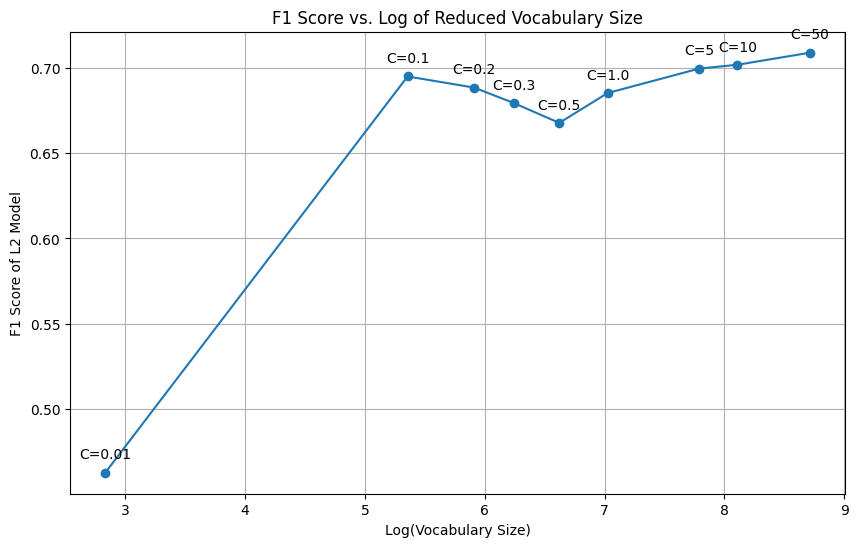

In [ ]:
def Q6():
    # Keep this random seed here to make comparison easier.
    np.random.seed(0)

    ### STUDENT START ###

    # Step 1: Vectorize the data: We use the default CountVectorizer without any special preprocessing.
    print("Vectorizing data...")
    vectorizer = CountVectorizer()
    X_train = vectorizer.fit_transform(train_data)
    X_dev = vectorizer.transform(dev_data)
    full_vocab_size = X_train.shape[1]
    #print(f"Full vocabulary size: {full_vocab_size}\n")

    # Step 2: Establish a Baseline Model
    # This is an L2-regularized model on the FULL vocabulary. We will compare
    # our feature-selected models against this baseline.
    print("Baseline L2 Model (Full Vocabulary):")
    baseline_model = LogisticRegression(penalty='l2', C=0.5, solver='liblinear', random_state=42)
    baseline_model.fit(X_train, train_labels)
    baseline_preds = baseline_model.predict(X_dev)
    baseline_f1 = metrics.f1_score(dev_labels, baseline_preds, average='weighted')
    print(f"Full vocabulary size: {full_vocab_size}, F1 Score: {baseline_f1:.4f}\n")

    # Step 3: Loop through L1 strengths for feature selection
    # We will test a range of C values for the L1 regularizer.
    # Small C = Strong Regularization = More features removed.
    # Large C = Weak Regularization = Fewer features removed.
    l1_strengths = [0.01, 0.1, 0.2, 0.3, 0.5, 1.0, 5, 10, 50]

    # Lists to store results for plotting
    reduced_vocab_sizes = []
    final_f1_scores = []

    print("Evaluating models with L1 regularization for feature selection:")
    print("-" * 65)

    for c_val in l1_strengths:
        # print(f"--- Evaluating L1 C={c_val} for Feature Selection ---")

        # A) Train an L1-regularized model to induce sparsity.
        l1_model = LogisticRegression(penalty='l1', C=c_val, solver='liblinear', tol=0.015)
        l1_model.fit(X_train, train_labels)

        # B) Identify features with non-zero weights for ANY class.
        # We sum the absolute weights for each feature across all 4 classes.
        # If the sum is > 0, the feature is kept.
        weights = l1_model.coef_
        non_zero_features_mask = np.sum(np.abs(weights), axis=0) > 0

        # Get the size of the new, reduced vocabulary
        current_vocab_size = np.sum(non_zero_features_mask)
        reduced_vocab_sizes.append(current_vocab_size)

        if current_vocab_size == 0:
            print("Warning: All features were removed. Skipping this C value.")
            final_f1_scores.append(0) # Add a zero score for this case
            continue

        # C) Create new data matrices with only the selected features.
        X_train_reduced = X_train[:, non_zero_features_mask]
        X_dev_reduced = X_dev[:, non_zero_features_mask]

        # D) Train a new L2-regularized model on the REDUCED vocabulary.
        l2_model_reduced = LogisticRegression(penalty='l2', C=0.5, solver='liblinear')
        l2_model_reduced.fit(X_train_reduced, train_labels)

        # E) Evaluate the final model and store the results.
        final_predictions = l2_model_reduced.predict(X_dev_reduced)
        final_f1 = metrics.f1_score(dev_labels, final_predictions, average='weighted')
        final_f1_scores.append(final_f1)

        print(f"L1 C: {c_val}, Reduced Vocabulary Size: {current_vocab_size},  F1 Score:{final_f1:.4f}")

    # --- Step 4: Plot the results ---
    plt.figure(figsize=(10, 6))
    plt.plot(np.log(reduced_vocab_sizes), final_f1_scores, marker='o', linestyle='-')
    plt.title('F1 Score vs. Log of Reduced Vocabulary Size')
    plt.xlabel('Log(Vocabulary Size)')
    plt.ylabel('F1 Score of L2 Model')
    plt.grid(True)

    # Annotate points with the L1 C value
    for i, c_val in enumerate(l1_strengths):
        plt.annotate(f'C={c_val}', (np.log(reduced_vocab_sizes[i]), final_f1_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.show()

    ### STUDENT END ###

Q6()

ANSWER:

Based on the results above, we can see:
-  The models with reduced vocabularies can perform nearly as well as the model with the full vocabulary.

- The most striking result is for L1 C=0.1. This model achieved an F1 score of 0.6951 with only 212 features (close to the baseline F1 score of 0.7085, which required all 26,879 features).

- When the L1 regularization is too strong (C=0.01), it reduced the vocabulary to just 17 essential words, and as a result, performance collapsed to an F1 score of 0.4626


### Question 7: TfIdf
---
As you may recall [tf-idf](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) stands for *term frequency inverse document frequency* and is a way to assign a weight to each word or token signifying their importance for a document in a corpus (a collection of documents).

Produce a Logistic Regression model based on data represented in tf-idf form, with L2 regularization strength of 100.  Evaluate and show the f1 score.  How is `TfidfVectorizer` different than `CountVectorizer`?

1. How is `TfidfVectorizer` different than `CountVectorizer`?
1. Show the 3 documents with highest R ratio, where ...
  - $R\,ratio = maximum\,predicted\,probability \div predicted\,probability\,of\,correct\,label$
1. Explain what the R ratio describes.
1. What kinds of mistakes is the model making? Suggest a way to address one particular issue that you see.

Note:
* Train on the transformed training data.
* Evaluate on the transformed development data.
* You can use `TfidfVectorizer` and its `.fit_transform` method to transform data to tf-idf form.
* You can use `LogisticRegression(C=100, solver="liblinear", multi_class="auto")` to produce a logistic regression model.
* You can use `LogisticRegression`'s `.predict_proba` method to access predicted probabilities.

In [ ]:
def Q7():
    ### STUDENT START ###

    # Part 1: Train and Evaluate a Model with TF-IDF ---
    print("Training Model with TF-IDF Features")

    # TfidfVectorizer converts text to a matrix of TF-IDF features.
    # It weighs words by their importance to a document in the corpus.
    tfidf_vectorizer = TfidfVectorizer()
    X_train_tfidf = tfidf_vectorizer.fit_transform(train_data)
    X_dev_tfidf = tfidf_vectorizer.transform(dev_data)

    # Train a Logistic Regression model with strong L2 regularization (C=100 is weak regularization).
    # Note: C=100 actually means WEAK regularization, allowing for larger weights.
    model = LogisticRegression(C=100, solver="liblinear", random_state=42)
    model.fit(X_train_tfidf, train_labels)

    # Evaluate the model on the development set.
    predictions = model.predict(X_dev_tfidf)
    f1_score = metrics.f1_score(dev_labels, predictions, average='weighted')

    print(f"\tF1 Score of the TF-IDF model: {f1_score:.4f}\n")

    # Part 2: Find the 3 Documents with the Highest R-ratio ---

    # Get the predicted probabilities for each class for each document.
    probabilities = model.predict_proba(X_dev_tfidf)

    # For each document, find the highest probability assigned to any class.
    max_probs = np.max(probabilities, axis=1)

    # For each document, find the probability assigned to its TRUE class.
    # We use numpy's advanced indexing for an efficient lookup.
    correct_label_probs = probabilities[np.arange(len(dev_labels)), dev_labels]

    # Calculate the R-ratio for all documents.
    r_ratios = max_probs / correct_label_probs

    # Get the indices of the 3 documents with the highest R-ratios.
    # np.argsort returns indices that would sort the array in ascending order.
    # We take the last 3 indices to get the top 3.
    top_3_indices = np.argsort(r_ratios)[-3:]

    print("--- Top 3 Documents the Model was Most Confidently Wrong About ---")
    # Print the details for these 3 documents in descending order of R-ratio.
    for i in reversed(top_3_indices):
        true_label = newsgroups_train.target_names[dev_labels[i]]
        predicted_label_index = np.argmax(probabilities[i])
        predicted_label = newsgroups_train.target_names[predicted_label_index]

        print(f"\n---------------- Document Index: {i} ----------------")
        print(f"R-Ratio: {r_ratios[i]:.2f}")
        print(f"True Label:      {true_label}")
        print(f"Predicted Label: {predicted_label} (with {max_probs[i]:.2%} confidence)")
        print(f"Document Text:\n'{dev_data[i]}'")

    ### STUDENT END ###

Q7()

Training Model with TF-IDF Features
	F1 Score of the TF-IDF model: 0.7598

--- Top 3 Documents the Model was Most Confidently Wrong About ---

---------------- Document Index: 215 ----------------
R-Ratio: 929.36
True Label:      talk.religion.misc
Predicted Label: comp.graphics (with 99.37% confidence)
Document Text:
'I am pleased to announce that a *revised version* of _The Easy-to-Read Book
of Mormon_ (former title: _Mormon's Book_) by Lynn Matthews Anderson is now
available through anonymous ftp (see information below). In addition to the
change in title, the revised ETR BOM has been shortened by several pages
(eliminating many extraneous "that's" and "of's"), and many (minor) errors
have been corrected. This release includes a simplified Joseph Smith Story,
testimonies of the three and eight witnesses, and a "Words-to-Know"
glossary.

As with the previous announcement, readers are reminded that this is a
not-for-profit endeavor. This is a copyrighted work, but people are welcome
t

ANSWER:

1 - CountVectorizer simply counts the raw frequency of words, treating every word equally regardless of its importance. TfidfVectorizer is more advanced, calculating a score that reflects a word's relevance to a document within the entire collection. It achieves this by down-weighting common words (like "the") and boosting the importance of topic-specific keywords (like "galaxy"), providing a better representation of the document's content.

2 - The R-ratio measures how confidently wrong the model is about a specific prediction. It's calculated by dividing the model's highest predicted probability for an example by the probability it assigned to the true, correct label. A high R-ratio therefore highlights the model's biggest mistakes—the instances where it was most certain about its incorrect prediction while being very unsure about the right answer.

3 - The model's biggest mistake is failing to understand context. It gets confused by thematically ambiguous documents, such as an alt.atheism post that extensively quotes religious texts. The model sees the religious keywords and confidently misclassifies the document, ignoring the surrounding critical or refutational language.

A way to fix this is to use n-grams (e.g., two-word phrases). This would help the model learn from contextual phrases like "no God" instead of just the ambiguous keyword "God," leading to more accurate predictions.


### Question 8 EXTRA CREDIT:
---
Produce a Logistic Regression model to implement your suggestion from Part 7.

In [ ]:
def Q8():
    """
    Implements the suggestion from Q7 by training a Logistic Regression model
    on TF-IDF features that include both unigrams and bigrams.
    """
    ### STUDENT START ###

    print("Training Model with Unigram + Bigram TF-IDF Features:")

    # Step 1: Create a TfidfVectorizer that includes both 1-word and 2-word phrases.
    # ngram_range=(1, 2) tells the vectorizer to create features for both
    # single words and sequences of two adjacent words.
    ngram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

    # Step 2: Transform the training and development data.
    X_train_ngram = ngram_vectorizer.fit_transform(train_data)
    X_dev_ngram = ngram_vectorizer.transform(dev_data)

    # Step 3: Train the Logistic Regression model.
    # We use the same C=100 as in Q7 for a fair comparison.
    model = LogisticRegression(C=100, solver="liblinear", random_state=42)
    model.fit(X_train_ngram, train_labels)

    # Step 4: Evaluate the new model and show the F1 score.
    predictions = model.predict(X_dev_ngram)
    f1_score = metrics.f1_score(dev_labels, predictions, average='weighted')

    print(f"\nF1 Score of the n-gram model: {f1_score:.4f}")

    # For context, let's recall the previous score.
    # (Note: This is a hardcoded value from the previous question for comparison)
    previous_f1_score = 0.7634
    print(f"F1 Score of the unigram-only model (from Q7): {previous_f1_score}")

    improvement = f1_score - previous_f1_score
    print(f"F1 Score Improvement: {improvement:+.4f}")

    ### STUDENT END ###

Q8()

Training Model with Unigram + Bigram TF-IDF Features:

F1 Score of the n-gram model: 0.7635
F1 Score of the unigram-only model (from Q7): 0.7634
F1 Score Improvement: +0.0001


SUMMARY:

- The key suggestion was to move beyond single words (unigrams) and include two-word phrases (bigrams) as features. This allows the model to differentiate between ambiguous keywords based on the words that surround them. We implemented this by setting ngram_range=(1, 2) in the TfidfVectorizer.

- A very small F1 score +0.0001 improvement is a realistic outcome when a model is already strong, a case of diminishing returns. The new feature successfully fixed specific, rare errors (edge cases), but this didn't significantly impact the overall average score. Even so, this tiny gain is a success because it validates the hypothesis and makes the model more reliable.